In [73]:
from itertools import count
from re import purge

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
import os

print(os.getcwd())
print(os.listdir())
import os

print(os.listdir("../../Week 3/Project/data"))

C:\Users\Rupali Waghmare\Documents\AIML\AI_ML\data-handling-pipeline\Month 2\Week 4\Project
['data', 'eda.ipynb']
['data_description.txt', 'Features_engineered_Housing_Dataset', 'train.csv']


In [75]:
df = pd.read_csv("../../Week 3/Project/data/Features_engineered_Housing_Dataset")
df.head(10)

,Unnamed: 0,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,ExterQual,ExterCond,BsmtQual,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Cluster
0,0,1,60,8450,7,5,2003,4,3,4,...,0,0,0,1,0,0,0,1,0,0
1,1,2,20,9600,6,8,1976,3,3,4,...,0,0,0,1,0,0,0,1,0,1
2,2,3,60,11250,7,5,2002,4,3,4,...,0,0,0,1,0,0,0,1,0,0
3,3,4,70,9550,7,5,1970,3,3,3,...,0,0,0,1,0,0,0,0,0,0
4,4,5,60,14260,8,5,2000,4,3,4,...,0,0,0,1,0,0,0,1,0,0
5,5,6,50,14115,5,5,1995,3,3,4,...,0,0,0,1,0,0,0,1,0,1
6,6,7,20,10084,8,5,2005,4,3,5,...,0,0,0,1,0,0,0,1,0,0
7,7,8,60,10382,7,6,1973,3,3,4,...,0,0,0,1,0,0,0,1,0,0
8,8,9,50,6120,7,5,1950,3,3,3,...,0,0,0,1,0,0,0,0,0,0
9,9,10,190,7420,5,6,1950,3,3,3,...,0,0,0,1,0,0,0,1,0,1



## **The Cleaning and Filling of Dataset is done in week 3 Project on Housing Dataset so here just deriving conclusion between different features and the target variable**

### **Every Step taken is done from help of data_description.csv**

### **1. Performing Univariate analysis on target variable { "SalePrice" }**

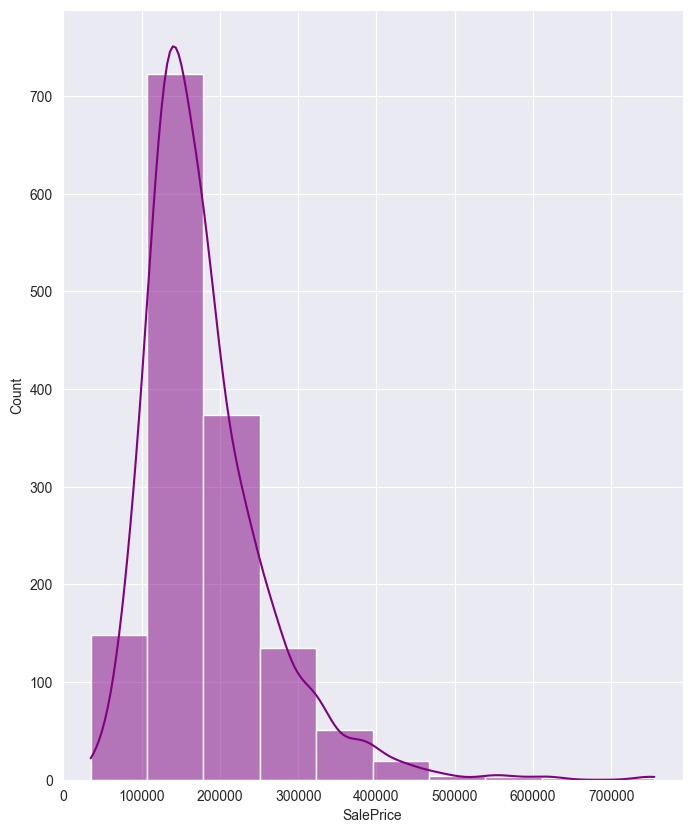

In [76]:
# 1. Histogram on SalePrice
plt.figure(figsize=(8,10))
sns.histplot(
    data = df,
    x='SalePrice',
    kde=True,
    #log_scale=True,  # Used to normalize data without this the data looks right skewed
    bins=10,
    color = "purple"
)
plt.show()

# Here it can be seen most of the houses (count = 700+) were sold between price 2 lakh - 3 lakh

<Axes: xlabel='SalePrice', ylabel='Density'>

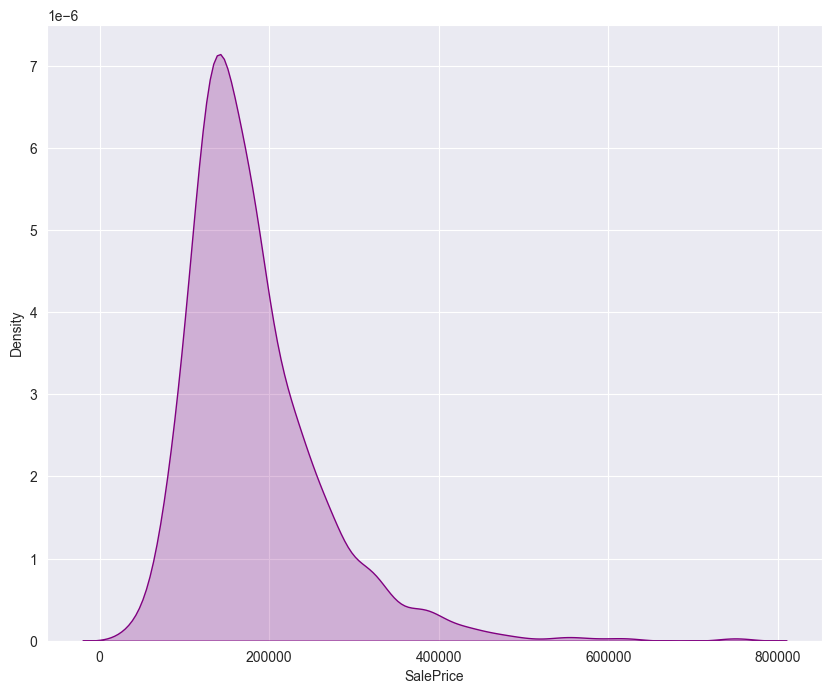

In [77]:
# Kde (Kernel Density Estimation)

plt.figure(figsize=(10,8))

sns.kdeplot(
    data=df,
    x = "SalePrice",
    fill=True,
    color="purple"
)

# This kde plot clears that the data is highly right skewed so need to use transformation for reducing and balancing the outliers

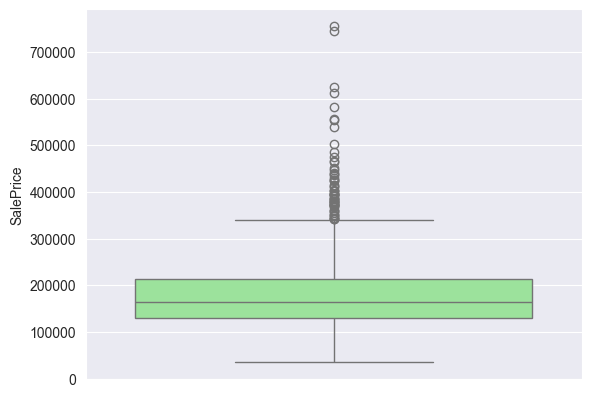

In [78]:
# Checking out the outliers in the data

sns.boxplot(
    data=df,
    y='SalePrice',
    orient='v',     # HERE if x = "" is give then it is by default horizontal orient because we say x = "" so number plotted on x axis
    color='lightgreen'
)
plt.show()

# Most of the data lies in Q2 that is between 1 lakh - 2 lakh
# The data set has some outliers but they are genuine one as fro also the histplot so large mansion cost more than 3.5 lakh (i.e is above 75 percentile of data )

### **2. Bivariate Analysis on the different features of the dataset and target variable ("SalePrice")**

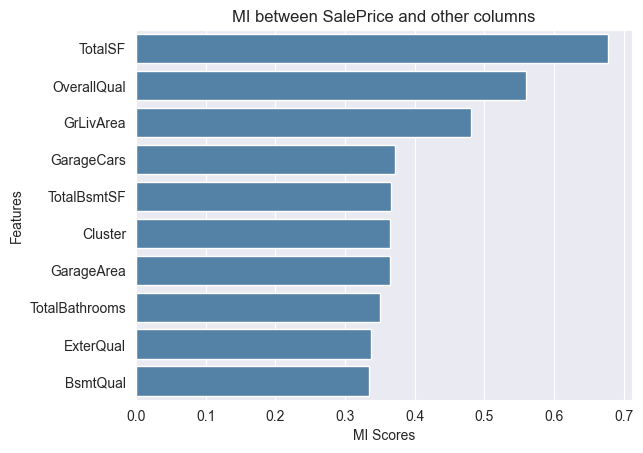

In [79]:
# Getting Mutual Information for the columns we derived in week 3 project file (Feature_Engineering.ipynb) for analysis

from sklearn.feature_selection import mutual_info_regression

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

mi_scores = mutual_info_regression(X,y)
mi_scores = pd.Series(mi_scores , index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

sns.barplot(
    x = mi_scores.head(10),
    y = mi_scores.head(10).index,
    color='steelblue'

)
plt.title("MI between SalePrice and other columns")
plt.xlabel("MI Scores")
plt.ylabel("Features")
plt.show()

# Here the highest MI scores features are TotalSF , QverallQual , GrLivArea

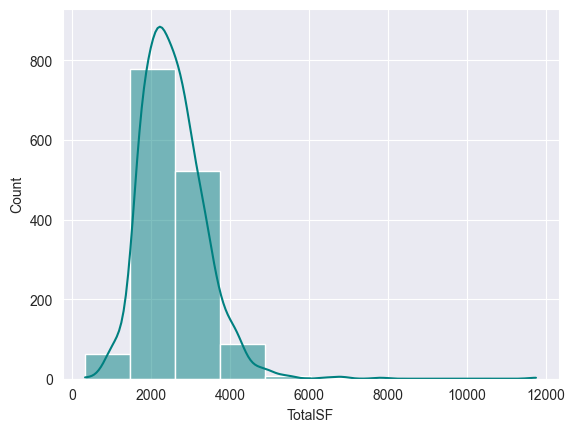

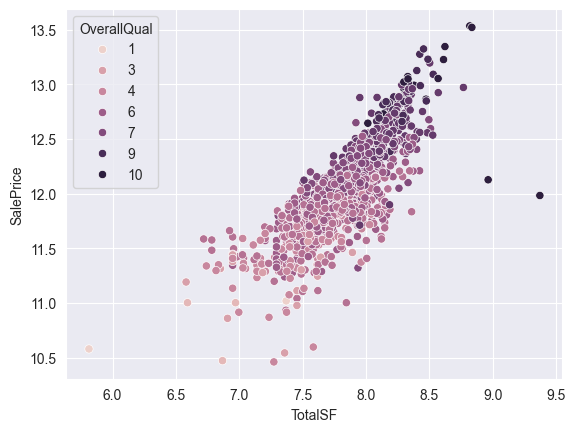

In [80]:
# 1. TotalSF V/S SalePrice (Numerical vs Numerical)

# Checking the spread of data
sns.histplot(
    data = df,
    x='TotalSF',
    kde=True,
    bins = 10,
    color = "teal"

)   # here we can see the data is rightly skewed
plt.show()

sns.scatterplot(
    data=df,
    x= np.log1p(df['TotalSF']),    # Log transformation as in rightly skewed is hard to interpret
    y = np.log1p(df['SalePrice']),
    hue = "OverallQual"

)
plt.show()

# Positive Relationship between TotalSF and SalePrice as surface area increase sale price increase and also the overall quality is high also increases

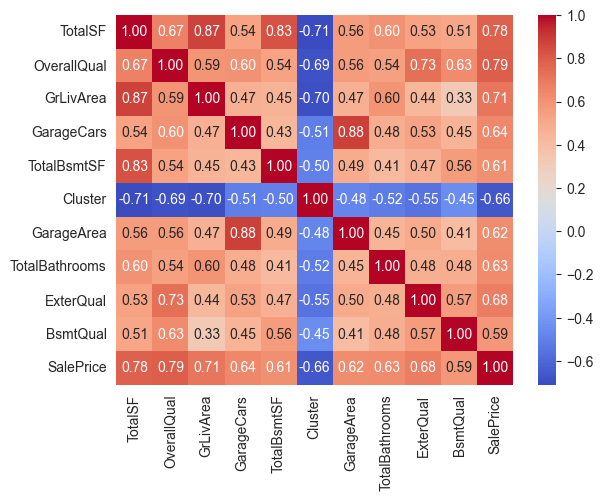

In [81]:
# Correlation between features

# The Features selected for correlation heatmap are the features with highest MI scores

top_10_features = mi_scores.head(10).index.tolist()

corr_data = df[top_10_features + ["SalePrice"]]   # here we take columns name form mi_scores and also added the SalePrice column as wee need correlation with it also
corr = corr_data.corr(
    method="pearson",
    numeric_only=True
)

sns.heatmap(
    data=corr,
    annot = True,
    fmt=".2f",
    cbar=True,
    cmap="coolwarm"
)
plt.show()

# Here we can conclude that the highly corr related feature with Target("SalePrice") are TotalSF , QverallQual , GrLivArea same as MI scores

### **3.Feature Engineering Analysis**

**From the file Feature_Engineering.ipynb the features we engineered namely TotalSF and TotalBathrooms**

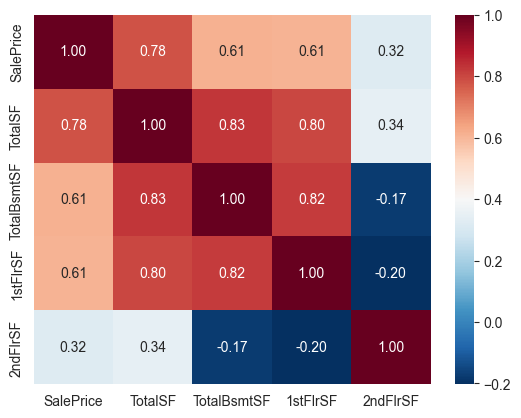

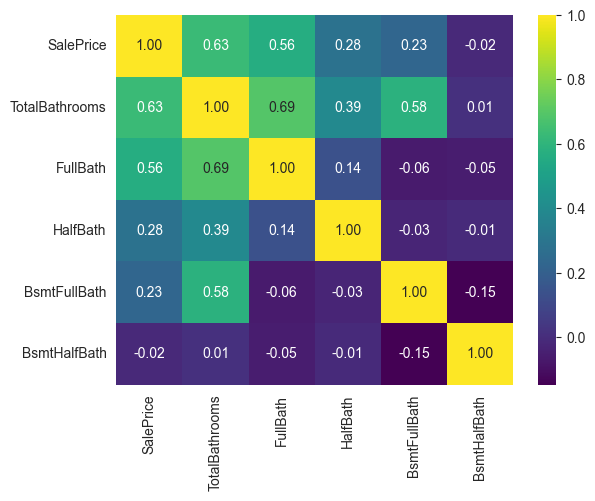

In [83]:
# Total Living Area

# df["TotalSF"] = (
#         df["TotalBsmtSF"]
#         + df["1stFlrSF"]
#         + df["2ndFlrSF"]
# )
#
# # Total Bathrooms
# df["TotalBathrooms"] = (
#         df["FullBath"]
#         + 0.5 * df["HalfBath"]
#         + df["BsmtFullBath"]
#         + 0.5 * df["BsmtHalfBath"]
# )

# This feature significantly increased the correlation with SalePrice and impacting it a lot


# Visual Difference

# 1. TotalSF

data = df[["SalePrice" , "TotalSF" , "TotalBsmtSF" , "1stFlrSF" , "2ndFlrSF"]]

corr_data = data.corr()

sns.heatmap(
    data = corr_data,
    annot=True,
    fmt= ".2f",
    cmap= "RdBu_r",
    cbar=True
)
plt.show()

# Insight: The engineered feature TotalSF, created by combining TotalBsmtSF, 1stFlrSF, and 2ndFlrSF, shows the strongest correlation with SalePrice (r = 0.78) compared to its individual components (TotalBsmtSF: 0.61, 1stFlrSF: 0.61, 2ndFlrSF: 0.32). This suggests that the overall usable area of a house is a better predictor of sale price than any single floor area alone. Buyers appear to value the total living space of a property rather than focusing on a specific level of the house.
# The relatively low correlation of 2ndFlrSF (0.32) indicates that second-floor area alone has a weaker influence on house prices.



# 2. "TotalBathrooms"

data = df[["SalePrice" , "TotalBathrooms" , "FullBath" , "HalfBath" , "BsmtFullBath" , "BsmtHalfBath"]]

corr_data = data.corr()

sns.heatmap(
    data = corr_data,
    annot=True,
    fmt= ".2f",
    cmap= "viridis",
    cbar=True
)
plt.show()


# Insight: The derived feature TotalBathrooms achieved the highest correlation with SalePrice (0.63), exceeding all individual bathroom features. This suggests that the total bathroom availability within a property is a more meaningful indicator of house value than separate bathroom counts. Furthermore, full bathrooms contribute substantially more to house prices than half or basement bathrooms.


## **Key Findings from the EDA from Week 3 and Week 4 Project**

### 1.

SalePrice exhibits a right-skewed distribution, indicating that expensive houses are less common.

### 2.

A log transformation of SalePrice reduces skewness and makes the distribution closer to normal.

### 3.

OverallQual is one of the strongest predictors of house prices, with higher-quality houses selling for substantially more.

### 4.

GrLivArea shows a strong positive relationship with SalePrice, suggesting that larger living areas command higher prices.

### 5.

TotalSF demonstrates a positive association with SalePrice, indicating that total usable space contributes to value.

### 6.

GarageCars and GarageArea are positively related to SalePrice, implying that larger garages increase property value.

### 7.

YearBuilt suggests that newer houses generally tend to have higher sale prices.

### 8.

Some extreme outliers remain present in a few numerical features, but they may represent genuine luxury properties rather than errors.

### 9.

Mutual Information analysis identified OverallQual, GrLivArea, and TotalSF among the most informative features.

### 10.

Engineered features provided additional predictive information beyond the original variables.

### 11.

Correlation analysis revealed several features with strong positive relationships with SalePrice.

### 12.

Certain highly correlated variables may introduce multicollinearity and should be considered carefully during model building.

### 13.

Scaling transformed feature ranges successfully without altering the underlying relationships between variables.

### 14.

K-Means clustering indicated the presence of distinct groups of houses with similar characteristics and pricing patterns.

### 15.

The combination of cleaning, feature engineering, and exploratory analysis resulted in a dataset that is well-prepared for machine learning tasks.